# Student Dropout Risk Prediction
## Notebook 4 — SHAP Analysis & Explainability

**Prerequisites:** Run `03_model_training_dropout_prediction.ipynb` first.

### Objectives
- Understand why the model makes each prediction
- Compute SHAP values for all students
- Visualise global feature importance via SHAP
- Generate per-student top risk factors
- Save SHAP outputs for the recommendation engine

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

shap.initjs()
print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Model & Data

In [2]:
# Load trained model
model = joblib.load('../models/xgboost_model.pkl')

# Load test data
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Load full processed data (all students — for app use)
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

FEATURE_NAMES = X_test.columns.tolist()

print(f'Model loaded.')
print(f'X_test shape  : {X_test.shape}')
print(f'X_train shape : {X_train.shape}')
print(f'Features      : {len(FEATURE_NAMES)}')

Model loaded.
X_test shape  : (885, 45)
X_train shape : (4804, 45)
Features      : 45


---
## 2. Compute SHAP Values

We use `TreeExplainer` — the fastest and most accurate SHAP method for tree-based models like XGBoost.

In [3]:
explainer = shap.TreeExplainer(model)

# Compute SHAP values for test set
shap_values = explainer.shap_values(X_test)

print(f'SHAP values computed.')
print(f'Shape: {shap_values.shape}  (rows=students, cols=features)')
print(f'\nPositive SHAP = pushes toward dropout')
print(f'Negative SHAP = pushes away from dropout')

SHAP values computed.
Shape: (885, 45)  (rows=students, cols=features)

Positive SHAP = pushes toward dropout
Negative SHAP = pushes away from dropout


---
## 3. Global SHAP Summary Plot

Shows which features have the most impact across all students, and whether high/low values push toward or away from dropout.

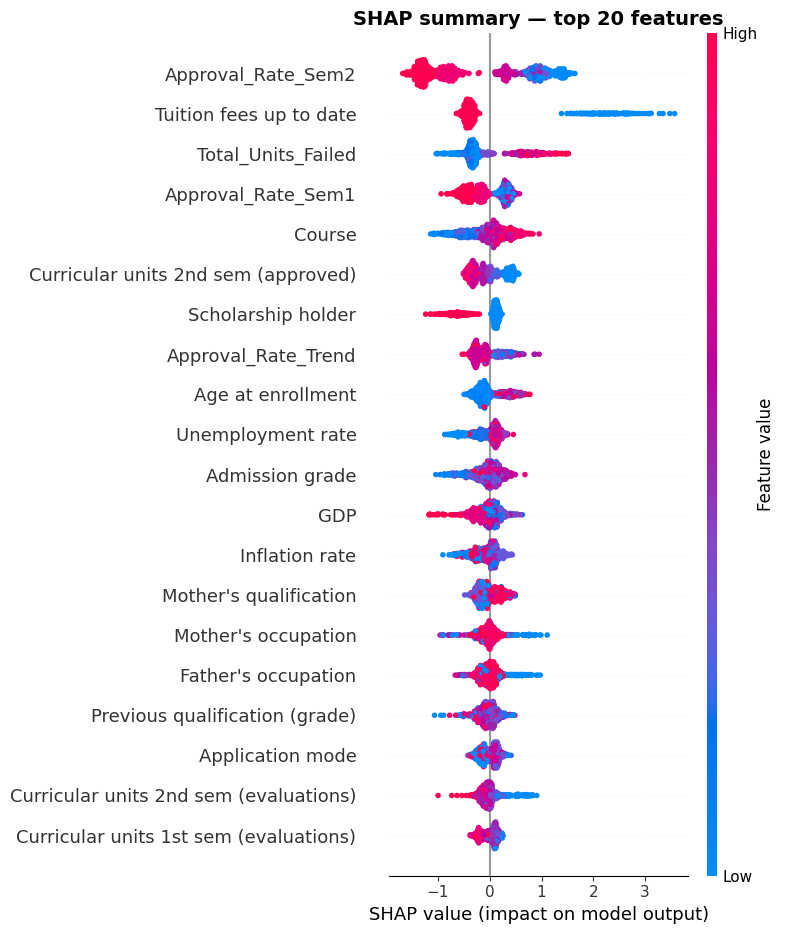

SHAP summary plot saved.


In [4]:
plt.figure(figsize=(11, 9))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURE_NAMES,
    max_display=20,
    show=False
)
plt.title('SHAP summary — top 20 features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP summary plot saved.')

---
## 4. Global SHAP Bar Plot

Mean absolute SHAP value per feature — a clean ranking of global feature importance.

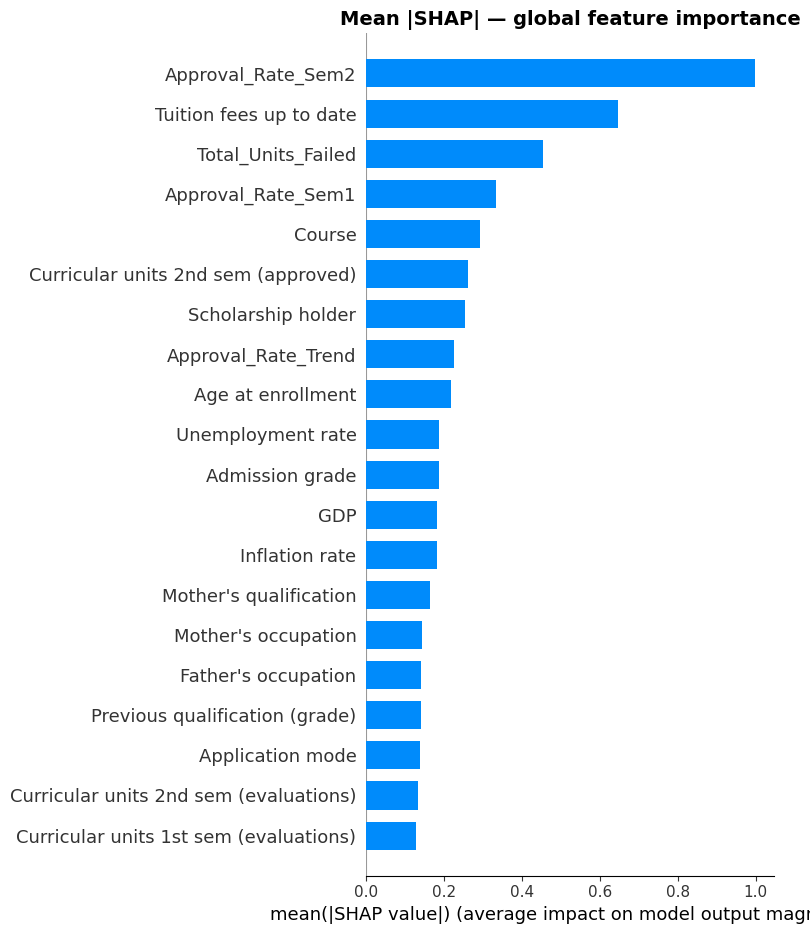

In [5]:
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURE_NAMES,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Mean |SHAP| — global feature importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. SHAP Dependence Plots

Shows how a single feature's value affects dropout risk across all students.

Top 4 features for dependence plots: ['Approval_Rate_Sem2', 'Tuition fees up to date', 'Total_Units_Failed', 'Approval_Rate_Sem1']


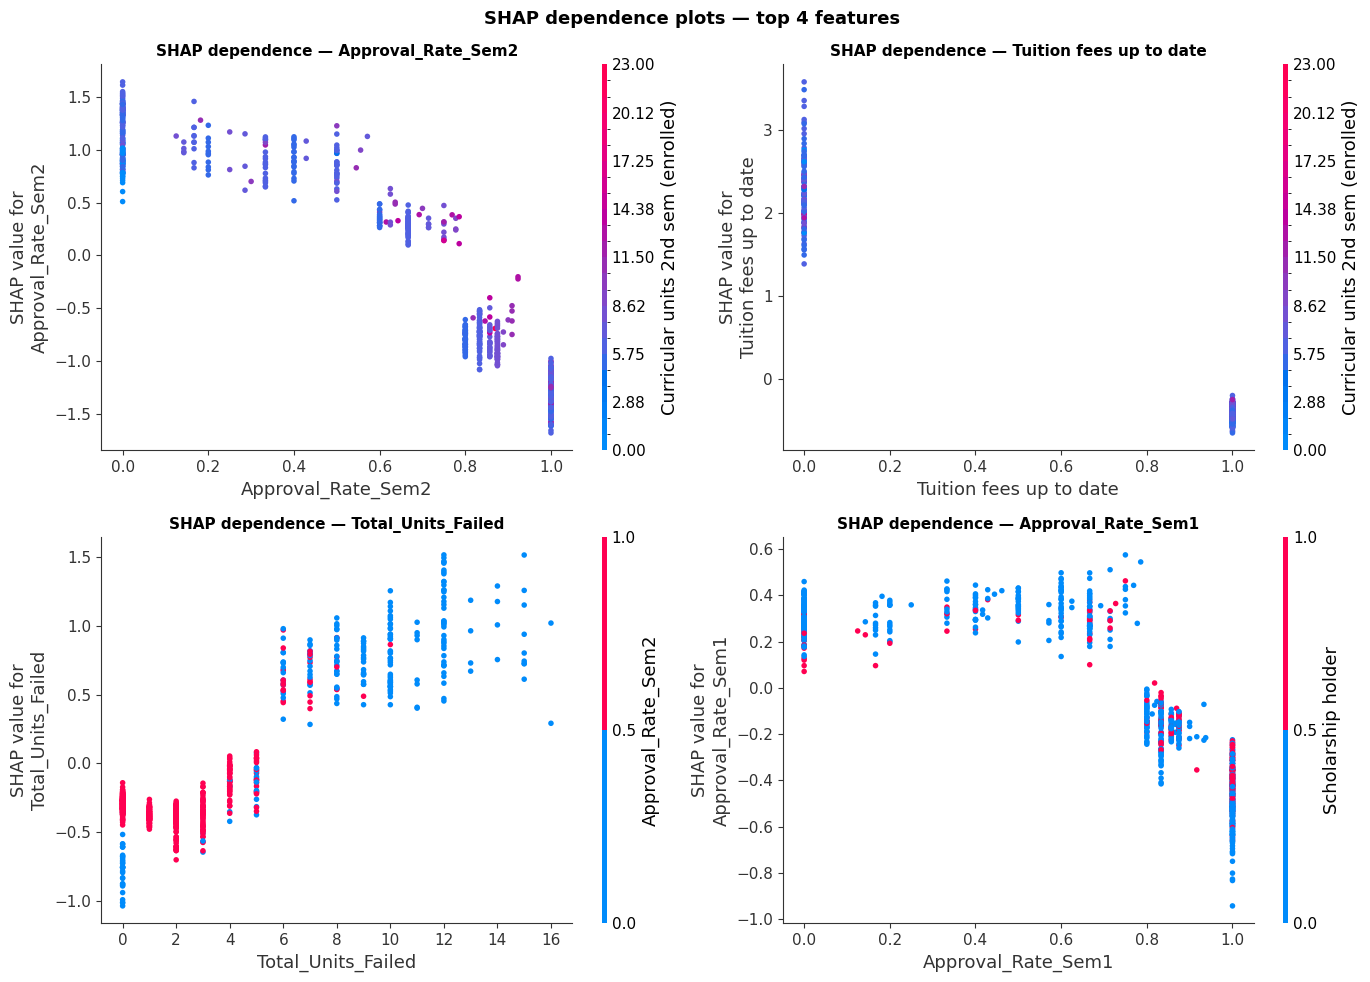

In [6]:
# Pick the top 4 features by mean |SHAP| for dependence plots
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)

top4_features = mean_shap.head(4).index.tolist()
print('Top 4 features for dependence plots:', top4_features)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, top4_features):
    shap.dependence_plot(
        feat,
        shap_values,
        X_test,
        feature_names=FEATURE_NAMES,
        ax=ax,
        show=False
    )
    ax.set_title(f'SHAP dependence — {feat}', fontweight='bold', fontsize=11)

plt.suptitle('SHAP dependence plots — top 4 features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Individual Student Explanations

Waterfall plots show exactly why the model assigned a particular risk score to a specific student.

In [7]:
# Get risk scores for test set
risk_scores = model.predict_proba(X_test)[:, 1]

# Find a high-risk and a low-risk student for illustration
high_risk_idx = np.argmax(risk_scores)
low_risk_idx  = np.argmin(risk_scores)

print(f'Highest risk student — index: {high_risk_idx}, score: {risk_scores[high_risk_idx]:.4f}')
print(f'Lowest risk student  — index: {low_risk_idx},  score: {risk_scores[low_risk_idx]:.4f}')

Highest risk student — index: 83, score: 0.9994
Lowest risk student  — index: 303,  score: 0.0010


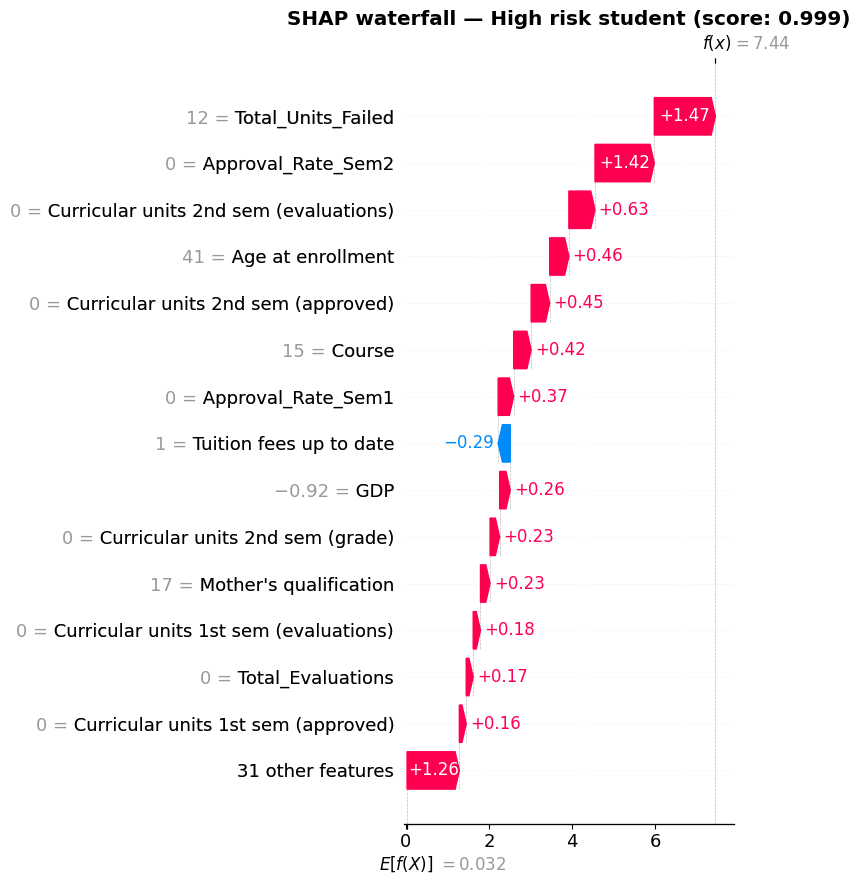

In [8]:
# Waterfall plot — HIGH risk student
explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx].values,
    feature_names=FEATURE_NAMES
)

plt.figure(figsize=(12, 7))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f'SHAP waterfall — High risk student (score: {risk_scores[high_risk_idx]:.3f})',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

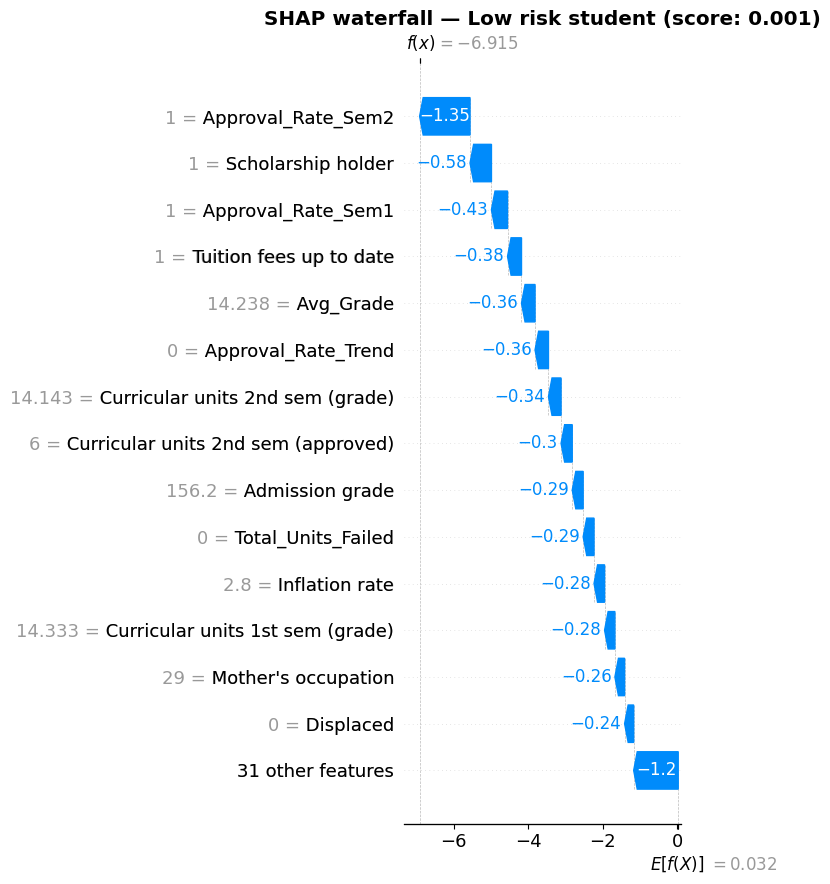

In [9]:
# Waterfall plot — LOW risk student
explanation_low = shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[low_risk_idx].values,
    feature_names=FEATURE_NAMES
)

plt.figure(figsize=(12, 7))
shap.plots.waterfall(explanation_low, max_display=15, show=False)
plt.title(f'SHAP waterfall — Low risk student (score: {risk_scores[low_risk_idx]:.3f})',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Extract Top Risk Factors Per Student

This is the critical output that feeds into the recommendation engine. For each student we extract their top 3 risk-driving features with their SHAP values and directions.

In [10]:
def get_top_risk_factors(shap_row, feature_names, feature_values, top_n=3):
    """
    For a single student, return the top N features driving dropout risk.
    Only considers features with POSITIVE SHAP values (pushing toward dropout).
    
    Returns a list of dicts with:
      - feature     : feature name
      - shap_value  : SHAP contribution
      - feature_val : actual value of that feature for this student
      - direction   : 'risk' (positive SHAP) or 'protective' (negative SHAP)
    """
    factors = []
    for i, (sv, fname, fval) in enumerate(zip(shap_row, feature_names, feature_values)):
        factors.append({
            'feature'    : fname,
            'shap_value' : round(float(sv), 4),
            'feature_val': round(float(fval), 4),
            'direction'  : 'risk' if sv > 0 else 'protective'
        })

    # Sort by absolute SHAP value, return top_n risk-driving factors
    risk_factors = [f for f in factors if f['direction'] == 'risk']
    risk_factors = sorted(risk_factors, key=lambda x: x['shap_value'], reverse=True)
    return risk_factors[:top_n]


# Apply to all students in test set
all_risk_factors = []

for idx in range(len(X_test)):
    top_factors = get_top_risk_factors(
        shap_values[idx],
        FEATURE_NAMES,
        X_test.iloc[idx].values
    )
    for rank, factor in enumerate(top_factors, 1):
        all_risk_factors.append({
            'student_index': idx,
            'risk_score'   : round(float(risk_scores[idx]), 4),
            'actual_label' : int(y_test.iloc[idx]),
            'rank'         : rank,
            **factor
        })

risk_factors_df = pd.DataFrame(all_risk_factors)

print(f'Risk factors extracted for {len(X_test)} students.')
print(f'Total rows: {len(risk_factors_df)} (3 factors × {len(X_test)} students)')
print()
risk_factors_df.head(9)

Risk factors extracted for 885 students.
Total rows: 2655 (3 factors × 885 students)



,student_index,risk_score,actual_label,rank,feature,shap_value,feature_val,direction
0,0,0.0188,0,1,Course,0.5358,13.0000,risk
1,0,0.0188,0,2,Admission grade,0.4181,135.9000,risk
2,0,0.0188,0,3,Displaced,0.1617,1.0000,risk
3,1,0.1147,0,1,Approval_Rate_Sem2,0.7300,0.4000,risk
4,1,0.1147,0,2,Approval_Rate_Trend,0.3959,-0.4000,risk
5,1,0.1147,0,3,Total_Evaluations,0.1136,20.0000,risk
6,2,0.9265,1,1,Approval_Rate_Sem2,1.2144,0.1667,risk
7,2,0.9265,1,2,Total_Units_Failed,0.7697,9.0000,risk
8,2,0.9265,1,3,Age at enrollment,0.6996,50.0000,risk


---
## 8. Most Common Risk Factors Across All Students

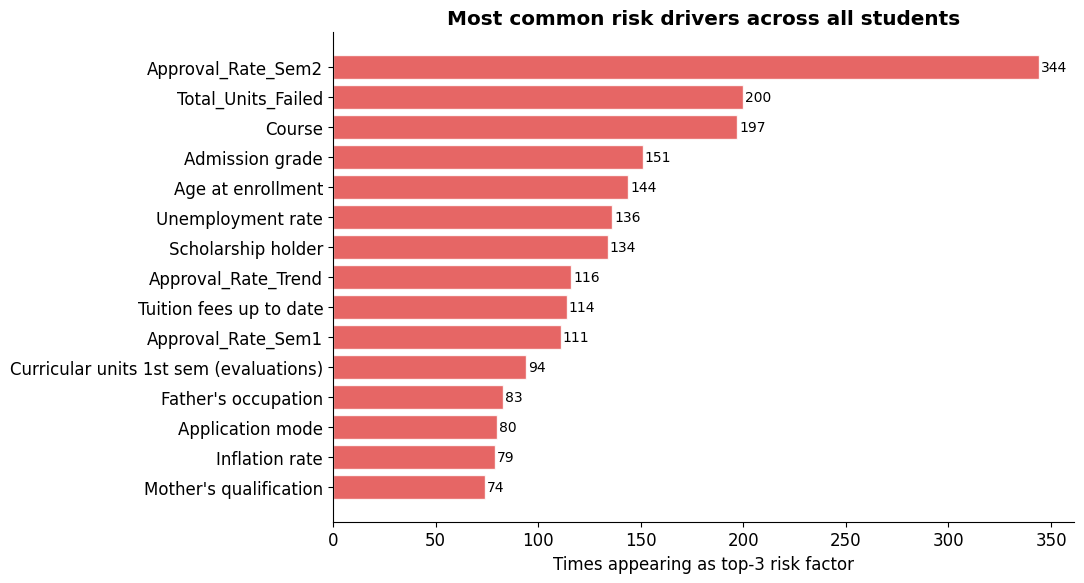

In [11]:
# Which features appear most often as a top-3 risk factor?
top_risk_feature_counts = (
    risk_factors_df[risk_factors_df['direction'] == 'risk']
    .groupby('feature')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top_risk_feature_counts.index[::-1],
    top_risk_feature_counts.values[::-1],
    color='#E24B4A', edgecolor='white', alpha=0.85
)
for bar, val in zip(bars, top_risk_feature_counts.values[::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Times appearing as top-3 risk factor')
ax.set_title('Most common risk drivers across all students', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/common_risk_factors.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. SHAP Values for Full Dataset

We compute SHAP values for the entire dataset (train + test) so the Streamlit app can show explanations for any uploaded student.

In [12]:
# Load full processed dataset
full_df = pd.read_csv('../data/processed/full_processed.csv')
X_full  = full_df[FEATURE_NAMES]

print(f'Computing SHAP for full dataset ({len(X_full)} students)...')
shap_values_full = explainer.shap_values(X_full)
print('Done.')

# Save SHAP values as a DataFrame
shap_df = pd.DataFrame(shap_values_full, columns=[f'shap_{f}' for f in FEATURE_NAMES])
shap_df['risk_score'] = model.predict_proba(X_full)[:, 1]
shap_df.to_csv('../data/processed/shap_values_full.csv', index=False)
print(f'Full SHAP values saved. Shape: {shap_df.shape}')

Computing SHAP for full dataset (4424 students)...
Done.
Full SHAP values saved. Shape: (4424, 46)


---
## 10. Save Risk Factors for Recommendation Engine

In [13]:
# Save per-student top risk factors
risk_factors_df.to_csv('../data/processed/student_risk_factors.csv', index=False)
print('Per-student risk factors saved to ../data/processed/student_risk_factors.csv')

# Save the explainer for use in Streamlit
joblib.dump(explainer, '../models/shap_explainer.pkl')
print('SHAP explainer saved to ../models/shap_explainer.pkl')

# Save mean SHAP importance ranking
mean_shap_df = mean_shap.reset_index()
mean_shap_df.columns = ['feature', 'mean_abs_shap']
mean_shap_df.to_csv('../data/processed/shap_feature_importance.csv', index=False)
print('SHAP feature importance saved.')

Per-student risk factors saved to ../data/processed/student_risk_factors.csv
SHAP explainer saved to ../models/shap_explainer.pkl
SHAP feature importance saved.


---
## 11. SHAP Summary

In [14]:
print('=' * 60)
print('  SHAP ANALYSIS SUMMARY')
print('=' * 60)
print(f"""
Students analysed : {len(X_test)} (test set)
Features          : {len(FEATURE_NAMES)}
Base value        : {explainer.expected_value:.4f}  (average model output)

Top 10 global risk drivers (mean |SHAP|)
""")
print(mean_shap.head(10).round(4).to_string())
print(f"""
Most common top-3 risk factor
  {top_risk_feature_counts.index[0]} ({top_risk_feature_counts.iloc[0]} students)

Saved artifacts
  ../models/shap_explainer.pkl
  ../data/processed/shap_values_full.csv
  ../data/processed/student_risk_factors.csv
  ../data/processed/shap_feature_importance.csv
  ../data/processed/shap_summary_plot.png
  ../data/processed/shap_bar_plot.png
  ../data/processed/shap_dependence_plots.png

Next step -> Notebook 05: Recommendation engine
""")
print('=' * 60)

  SHAP ANALYSIS SUMMARY

Students analysed : 885 (test set)
Features          : 45
Base value        : 0.0319  (average model output)

Top 10 global risk drivers (mean |SHAP|)

Approval_Rate_Sem2                     0.9974
Tuition fees up to date                0.6472
Total_Units_Failed                     0.4537
Approval_Rate_Sem1                     0.3331
Course                                 0.2911
Curricular units 2nd sem (approved)    0.2613
Scholarship holder                     0.2549
Approval_Rate_Trend                    0.2266
Age at enrollment                      0.2177
Unemployment rate                      0.1880

Most common top-3 risk factor
  Approval_Rate_Sem2 (344 students)

Saved artifacts
  ../models/shap_explainer.pkl
  ../data/processed/shap_values_full.csv
  ../data/processed/student_risk_factors.csv
  ../data/processed/shap_feature_importance.csv
  ../data/processed/shap_summary_plot.png
  ../data/processed/shap_bar_plot.png
  ../data/processed/shap_dependenc